In [2]:
# ==========================================
# LAB 2 - LINEAR REGRESSION WITH TENSORFLOW
# Dataset: 23_HOMES.csv
# ==========================================
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# 1. Đọc dữ liệu

url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/23_HOMES.csv"

df = pd.read_csv(url)

print("5 dòng đầu:")
print(df.head())

print("\nThông tin dữ liệu:")
print(df.info())

# 2. Làm sạch dữ liệu
# Xóa khoảng trắng tên cột
df.columns = df.columns.str.strip()

# Kiểm tra null
print("\nDữ liệu null:")
print(df.isnull().sum())

# Xóa null
df = df.dropna()

# Xóa dữ liệu trùng
df = df.drop_duplicates()

print("\nKích thước dữ liệu sau cleaning:")
print(df.shape)
# 3. Chọn input và output
# Giả sử cột cuối là giá nhà
X = df.iloc[:, :-1]
# Outputs
y = df.iloc[:, -1]
print("\nInput shape:", X.shape)
print("Output shape:", y.shape)
# 4. Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# 5. Chuẩn hóa dữ liệu (Z-score)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Lưu scaler
joblib.dump(scaler, "home_scaler.pkl")
print("\nĐã lưu scaler!")

# 6. Xây dựng Linear Regression
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        1,
        input_shape=(X_train_scaled.shape[1],)
    )
])
# Compile model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# 7. Huấn luyện model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    batch_size=8,
    validation_split=0.2
)

# 8. Predict
y_pred = model.predict(X_test_scaled)

# 9. Đánh giá model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== KẾT QUẢ =====")
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# 10. Lưu model
model.save("linear_regression_home_model.h5")
print("\nĐã lưu model!")
# 11. Dự đoán dữ liệu mới

loaded_scaler = joblib.load("home_scaler.pkl")
sample_house = X_test.iloc[:1]
sample_scaled = loaded_scaler.transform(sample_house)
predicted_price = model.predict(sample_scaled)
print("\nGiá nhà dự đoán:")
print(predicted_price)

5 dòng đầu:
   Selling_Price  List_Price  Area  Acres  Age  Taxes  Rooms  Bedrooms  \
0         400000      414000  2704   2.27   27   4920      9         3   
1         370000      379000  2096   0.75   21   4113      8         4   
2         382500      389900  2737   1.00   36   6072      9         4   
3         300000      299900  1800   0.43   34   4024      8         4   
4         305000      319900  1066   3.60   69   3562      6         3   

   Baths_full  
0           3  
1           2  
2           2  
3           2  
4           2  

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  40 non-null     int64  
 1   List_Price     40 non-null     int64  
 2   Area           40 non-null     int64  
 3   Acres          40 non-null     float64
 4   Age            40 non-null     int64  
 5   Taxes       

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 4.3620 - mae: 1.8846 - val_loss: 5.5398 - val_mae: 1.9824
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 4.3352 - mae: 1.8791 - val_loss: 5.5185 - val_mae: 1.9817
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 4.3082 - mae: 1.8736 - val_loss: 5.4988 - val_mae: 1.9813
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 4.2826 - mae: 1.8686 - val_loss: 5.4807 - val_mae: 1.9801
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 4.2615 - mae: 1.8642 - val_loss: 5.4631 - val_mae: 1.9786
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 4.2408 - mae: 1.8597 - val_loss: 5.4435 - val_mae: 1.9776
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 4.2173 - mae: 1.8548 - val_loss: 5.4251 - val_mae: 1.9760
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 4.1962 - mae: 1.8503 - val_loss: 5.4074 - val_mae: 1.9739
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 4.1760 - mae: 1.8459 - 


===== KẾT QUẢ =====
MSE: 2.8658335208892822
MAE: 1.6107845306396484
R2 Score: -6.974493503570557

Đã lưu model!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

Giá nhà dự đoán:
[[0.21949404]]


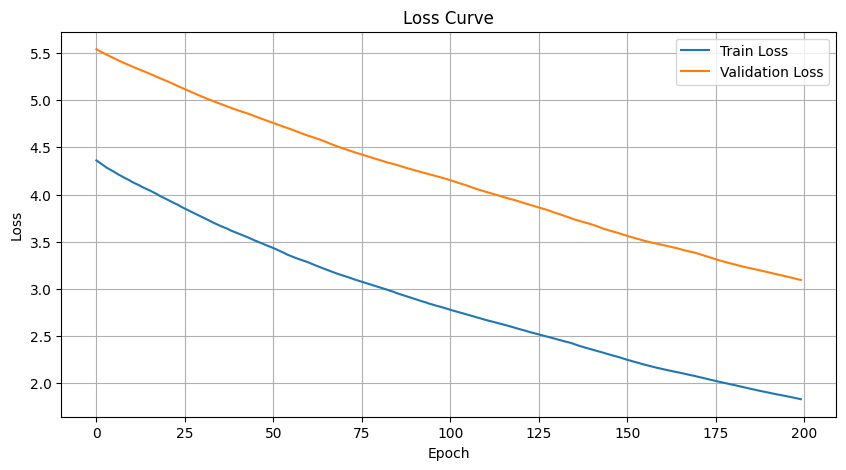

In [3]:
# ==========================================
# VẼ LOSS CURVE
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
# Train Loss
plt.plot(history.history['loss'], label='Train Loss')
# Validation Loss
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.grid(True)

plt.show()